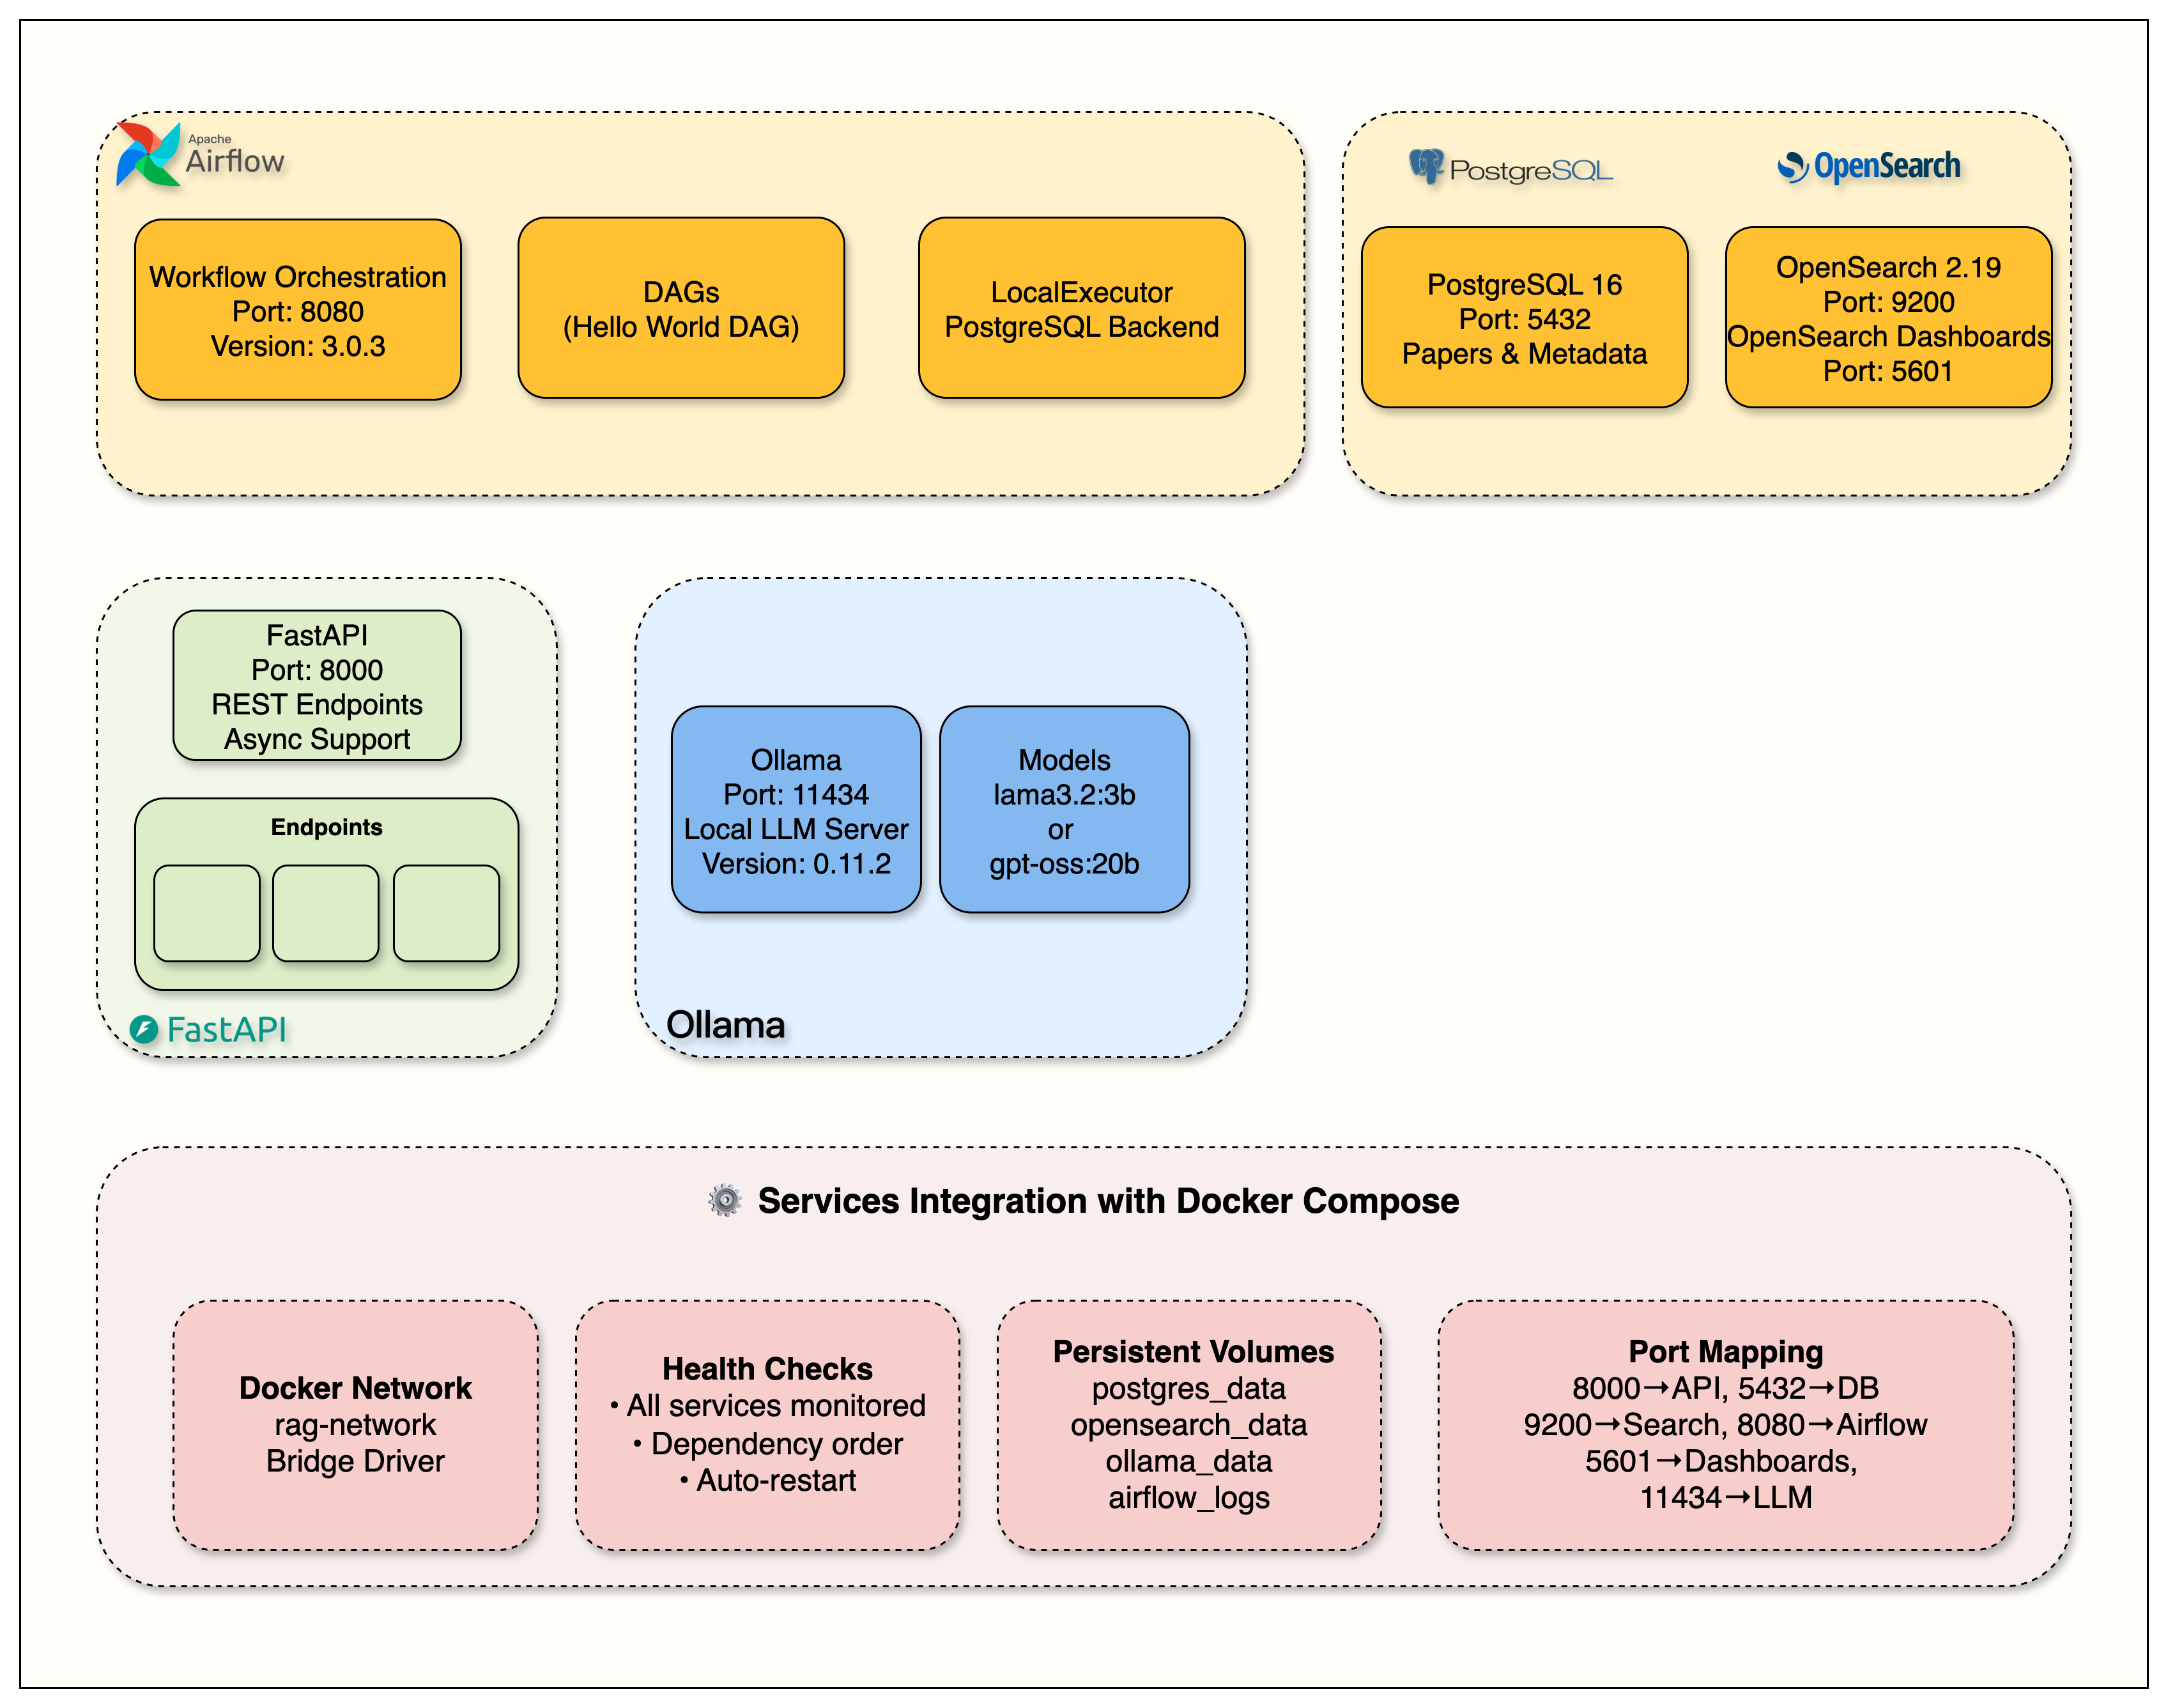

### Architecture Overview:

1. FastAPI (Port 8000): REST API with async support and automatic documentation
2. PostgreSQL 16 (Port 5432): Primary database for paper metadata and content storage
3. OpenSearch 2.19 (Ports 9200, 5601): Hybrid search engine with management dashboards
4. Apache Airflow 3.0 (Port 8080): Workflow orchestration with DAGs and PostgreSQL backend
5. Ollama (Port 11434): Local LLM server for future RAG implementation
6. Docker Network: All services communicate via rag-network with persistent volumes


Service-by-Service Setup

1. PostgreSQL database for paper metadata storage
2. OpenSearch for full-text search capabilities
3. Apache Airflow for workflow automation
4. Ollama for local LLM inference
5. FastAPI for REST API endpoints

Verification and Testing

1. Automated health checks for all services
2. Step-by-step verification procedures
3. Modular Ollama testing (4 focused test cells)
4. Common troubleshooting scenarios and solutions

In [14]:
# Environment Check
import sys

python_version = sys.version_info
print(f"Python Version: {python_version.major}.{python_version.minor}.{python_version.micro}")
print(f"Environment: {sys.executable}")

if python_version >= (3, 12):
    print("✓ Python version compatible")
else:
    print("✗ Need Python 3.12+")
    exit()

Python Version: 3.12.0
Environment: c:\Users\shubh\AppData\Local\Programs\Python\Python312\python.exe
✓ Python version compatible


In [15]:
from pathlib import Path

# Find Project Root
current_dir = Path.cwd()

if current_dir.name == "week1" and current_dir.parent.name == "notebooks":
    project_root = current_dir.parent.parent
elif (current_dir / "compose.yml").exists():
    project_root = current_dir
else:
    project_root = None

if project_root and (project_root / "compose.yml").exists():
    print(f"✓ Project root: {project_root}")
else:
    print("✗ Missing compose.yml - check directory")
    exit()


✓ Project root: c:\Users\shubh\OneDrive\Documents\Axriv Paper Curator RAG


In [16]:
# Check Docker
import subprocess

try:
    result = subprocess.run(["docker", "--version"], capture_output=True, text=True, timeout=5)
    if result.returncode == 0:
        print(f"✓ Docker: {result.stdout}")
    else:
        print("✗ Docker: Not working")
        exit()
except:
    print("✗ Docker: Not found")
    exit()

✓ Docker: Docker version 29.1.3, build f52814d



In [17]:
# Check Docker Compose
try:
    result = subprocess.run(["docker", "compose", "version"], capture_output=True, text=True, timeout=5)
    if result.returncode == 0:
        print(f"✓ Docker Compose: {result.stdout.split()[3]}")
    else:
        print("✗ Docker Compose: Not working")
        exit()
except:
    print("✗ Docker Compose: Not found")
    exit()

✓ Docker Compose: v5.0.1


In [18]:
# Check UV Package Manager
try:
    result = subprocess.run(["uv", "--version"], capture_output=True, text=True, timeout=5)
    if result.returncode == 0:
        print(f"✓ UV: {result.stdout.strip()}")
        print("\n✓ All required software ready!")
    else:
        print("✗ UV: Not working")
        exit()
except:
    print("✗ UV: Not found")
    exit()

✓ UV: uv 0.9.28 (0e1351e40 2026-01-29)

✓ All required software ready!


### Start Services

Command to run (in terminal):

1. cd [project-root]
2. docker compose up -d

What this does: Downloads images (first time) and starts all services in background.

In [19]:
# Check Docker Running
try:
    result = subprocess.run(
        ["docker", "info"],
        capture_output=True,
        encoding="utf-8",
        errors="replace",
        timeout=5,
    )

    if result.returncode == 0:
        print("✓ Docker is running")
    else:
        print("✗ Docker not running - start Docker Desktop")
except Exception as e:
    print(f"✗ Docker daemon not accessible: {e}")

✓ Docker is running


In [20]:
# Check Current Containers
import json

try:
    result = subprocess.run(
        ["docker", "compose", "ps", "--format", "json"],
        cwd=str(project_root),
        capture_output=True,
        encoding="utf-8",
        text=True,
        timeout=10
    )
    
    if result.returncode == 0 and result.stdout.strip():
        print("Current containers:")
        for line in result.stdout.strip().split('\n'):
            if line.strip():
                try:
                    container = json.loads(line)
                    service = container.get('Service', 'unknown')
                    state = container.get('State', 'unknown')
                    print(f"  • {service}: {state}")
                except:
                    pass
    else:
        print("No containers running")
        
except Exception as e:
    print("Could not check containers")

Current containers:
  • airflow: running
  • clickhouse: running
  • opensearch-dashboards: running
  • langfuse-minio: running
  • langfuse-postgres: running
  • langfuse-redis: running
  • langfuse-web: running
  • langfuse-worker: running
  • ollama: running
  • opensearch: running
  • postgres: running
  • redis: running


### Service Health Verification
All services start automatically. Check their health status:

In [21]:
# Service Health Check
EXPECTED_SERVICES = {
    'api': 'FastAPI REST API server',
    'postgres': 'PostgreSQL database',
    'opensearch': 'OpenSearch search engine', 
    'opensearch-dashboards': 'OpenSearch web dashboard',
    'ollama': 'Local LLM inference server',
    'airflow': 'Workflow automation (optional - may be off)'
}

try:
    result = subprocess.run(
        ["docker", "compose", "ps", "--format", "json"],
        cwd=str(project_root),
        capture_output=True,
        encoding="utf-8",
        text=True,
        timeout=15
    )
    
    if result.returncode == 0:
        print("SERVICE STATUS")
        print("=" * 70)
        print(f"{'Service':<20} {'State':<15} {'Status':<15} {'Notes'}")
        print("-" * 70)
    else:
        print("Could not get service status")
        exit()
        
except Exception as e:
    print(f"Error checking services: {e}")
    exit()

# Parse Service Status
found_services = set()
service_states = {}

if result.stdout.strip():
    for line in result.stdout.strip().split('\n'):
        if line.strip():
            try:
                container = json.loads(line)
                service = container.get('Service', 'unknown')
                state = container.get('State', 'unknown')
                health = container.get('Health', 'no check')
                
                found_services.add(service)
                service_states[service] = {'state': state, 'health': health}
                
                if state == 'running' and health in ['healthy', 'no check']:
                    indicator = "✓"
                    notes = "Ready"
                elif state == 'running' and health == 'unhealthy':
                    indicator = "⚠"
                    notes = "Starting up..."
                elif state == 'exited':
                    indicator = "✗"
                    notes = "Failed to start"
                else:
                    indicator = "?"
                    notes = f"Status: {state}"
                
                print(f"{indicator} {service:<18} {state:<14} {health:<14} {notes}")
                
            except json.JSONDecodeError:
                pass

SERVICE STATUS
Service              State           Status          Notes
----------------------------------------------------------------------
✓ airflow            running        healthy        Ready
✓ clickhouse         running        healthy        Ready
✓ opensearch-dashboards running        healthy        Ready
✓ langfuse-minio     running        healthy        Ready
✓ langfuse-postgres  running        healthy        Ready
✓ langfuse-redis     running        healthy        Ready
? langfuse-web       running        starting       Status: running
? langfuse-worker    running                       Status: running
✓ ollama             running        healthy        Ready
✓ opensearch         running        healthy        Ready
✓ postgres           running        healthy        Ready
✓ redis              running        healthy        Ready


In [22]:
# Check Missing Services
missing_services = set(EXPECTED_SERVICES.keys()) - found_services

if missing_services:
    print("\nMISSING SERVICES:")
    print("-" * 70)
    for service in missing_services:
        description = EXPECTED_SERVICES[service]
        if service == 'airflow':
            print(f"⚠ {service:<18} not running    {'(Optional)':<14} {description}")
        else:
            print(f"✗ {service:<18} not running    {'Required':<14} {description}")

failed_services = [s for s, info in service_states.items() 
                  if info['state'] in ['exited', 'restarting'] or info['health'] == 'unhealthy']

if failed_services:
    print(f"\nTROUBLESHOOTING:")
    for service in failed_services:
        print(f"   docker compose logs {service}")
elif missing_services and 'airflow' not in missing_services:
    print(f"\nACTION NEEDED:")
    print("Start missing services: docker compose up -d")


MISSING SERVICES:
----------------------------------------------------------------------
✗ api                not running    Required       FastAPI REST API server

ACTION NEEDED:
Start missing services: docker compose up -d


### 1. FastAPI - REST API Service
Interactive Exploration:

You can explore and test the FastAPI service in several ways:

API Documentation: http://localhost:8000/docs (Interactive Swagger UI)

Alternative Docs: http://localhost:8000/redoc (ReDoc interface)

Source Code: Located in src/routers/ directory

Let's test the API endpoints and explore the documentation:

In [23]:
# Test FastAPI Health
import requests

try:
    response = requests.get("http://localhost:8000/api/v1/health", timeout=5)
    if response.status_code == 200:
        data = response.json()
        print("✓ FastAPI is responding")
        print(f"Status: {data.get('status', 'unknown')}")
    else:
        print(f"⚠ API returned status: {response.status_code}")
except requests.exceptions.ConnectionError:
    print("✗ API not responding - wait 1-2 minutes")
except Exception as e:
    print(f"✗ API test error: {e}")

✗ API not responding - wait 1-2 minutes


In [24]:
# PRODUCTION INSIGHTS
print("\n" + "="*60)
print("  PRODUCTION INSIGHT (Online Sessions Only)")
print("="*60)
print("❓ How are they scaled?")
print("❓ What are the bottlenecks?")
print("❓ How are they monitored and managed?")
print("❓ How are they integrated with other systems?")
print("❓ What are the best practices for using these systems?")
print("❓ How are these systems used and deployed in production?")
print("❓ How are they tested? in terms of load and performance?")
print("→ Learn these production secrets in our online walkthrough sessions!")
print("="*60)


  PRODUCTION INSIGHT (Online Sessions Only)
❓ How are they scaled?
❓ What are the bottlenecks?
❓ How are they monitored and managed?
❓ How are they integrated with other systems?
❓ What are the best practices for using these systems?
❓ How are these systems used and deployed in production?
❓ How are they tested? in terms of load and performance?
→ Learn these production secrets in our online walkthrough sessions!


### 2. Apache Airflow - Workflow Automation
Interactive Exploration:

Apache Airflow manages data pipelines and automated workflows. You can explore it through:

Web Dashboard: http://localhost:8080 

Login: Username: admin, Password: Found in container (see test below)

Source Code: Located in airflow/dags/ directory

Simple Password Location: Airflow 3.0 stores the admin password in a predictable file:


/opt/airflow/simple_auth_manager_passwords.json.generated

The test below automatically reads this file for you!


Let's test Airflow and get the password:


In [25]:
# Get Airflow Password
import json
from pathlib import Path

password_file = project_root / "airflow" / "simple_auth_manager_passwords.json.generated"

try:
    if password_file.exists():
        with open(password_file, 'r') as f:
            data = json.load(f)
            password = data.get("admin")
        print(f"✓ Airflow password: {password}")
    else:
        print(f"⚠ Password file not found")
        password = None
except Exception as e:
    print(f"✗ Could not read password: {e}")
    password = None

⚠ Password file not found


In [26]:
# Test Airflow Health
try:
    response = requests.get("http://localhost:8080/api/v1/health", timeout=5)
    if response.status_code == 200:
        print("✓ Airflow is healthy")
        
        if password:
            print(f"\nAirflow Login:")
            print(f"URL: http://localhost:8080")
            print(f"Username: admin")
            print(f"Password: {password}")
    else:
        print(f"⚠ Airflow returned: {response.status_code}")
        
except requests.exceptions.ConnectionError:
    print("✗ Airflow not responding - wait 2-3 minutes")
except Exception as e:
    print(f"✗ Airflow test error: {e}")

✓ Airflow is healthy
